# Clasificación de Flores con Transfer Learning (MobileNetV2)

Clasificador de 5 flores (daisy, dandelion, rose, sunflower, tulip) usando MobileNetV2 pre-entrenado en ImageNet.

**Tecnologías:** PyTorch (deep learning), MobileNetV2 (red liviana de Google), torchvision (modelos + augmentations), scikit-learn (métricas), matplotlib (gráficos), PIL (imágenes), tqdm (barra de progreso).

**Dataset:** Flowers Recognition (Kaggle) - 4317 fotos, 800 por clase.

**Secciones:** 1. Imports | 2. Config | 3. Explorar datos | 4. Aumentar datos | 5. Modelo | 6. Entrenar | 7. Evaluar | 8. Inferencia

---


## 1. Importar dependencias


In [24]:
# --- 1. IMPORTAR DEPENDENCIAS ---
import sys, os, random, shutil
from pathlib import Path

import torch
import torch.nn as nn                    # Capas de la red
from torch.optim import Adam             # Optimizador
from torch.utils.data import DataLoader  # Carga datos en lotes
from torchvision import transforms, datasets, models  # Augmentations, datasets, modelos
from PIL import Image                    # Procesar imágenes
import numpy as np                       # Operaciones con números
import matplotlib.pyplot as plt          # Gráficos
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay  # Métricas
from tqdm import tqdm                    # Barra de progreso

# Información del entorno
print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')

# Usar GPU si hay, sino CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# Encontrar la carpeta raíz del proyecto (donde está .git)
def find_project_root():
    current = Path.cwd()
    while not (current / '.git').exists():
        current = current.parent
        if current.parent == current:
            return Path.cwd()
    return current

PROJECT_ROOT = find_project_root()
print(f'Raíz del proyecto: {PROJECT_ROOT}')


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.12.0+cpu
CUDA disponible: False
Usando dispositivo: cpu
Raíz del proyecto: c:\Users\ivans\Documents\proyectos-personales\flower-classification-transfer-learning\flower-classification-transfer-learning


## 2. Constantes y configuración


In [25]:
# --- 2. CONFIGURACIÓN ---
from pathlib import Path

# Encontrar la carpeta raíz del proyecto
def find_project_root():
    current = Path.cwd()
    while not (current / '.git').exists():
        current = current.parent
        if current.parent == current:
            return Path.cwd()
    return current

PROJECT_ROOT = find_project_root()

CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']  # Las 5 flores
NUM_CLASSES = len(CLASSES)
IMG_SIZE = 224           # Tamaño de imagen que espera MobileNetV2

# Valores para normalizar (estándar de ImageNet)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

BATCH_SIZE = 32          # Cuántas fotos procesa a la vez
EPOCHS = 20              # Veces que repite todo el dataset
LR = 1e-3                # Velocidad de aprendizaje (qué tan rápido aprende)
DROPOUT = 0.3            # Apaga 30% de neuronas al azar (evita sobreajuste)

# Rutas
DATA_DIR = str(PROJECT_ROOT / 'data' / 'split')                         # Datos separados en train/val/test
MODEL_PATH = str(PROJECT_ROOT / 'models' / 'best_model.pth')            # El mejor modelo guardado

print(f'Clases: {CLASSES}')
print(f'Cantidad de clases: {NUM_CLASSES}')
print(f'Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size: {BATCH_SIZE}')


Clases: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Cantidad de clases: 5
Tamaño de imagen: 224x224
Batch size: 32


## 3. Exploración del Dataset

El dataset **Flowers Recognition** contiene ~4,317 imágenes de flores divididas en 5 carpetas. Cada carpeta tiene entre 733 y 1052 fotos.

Las imágenes fueron separadas en:
- **70% entrenamiento (train):** para que el modelo aprenda
- **15% validación (val):** para elegir el mejor modelo durante el entrenamiento
- **15% prueba (test):** para medir el resultado final con fotos que el modelo nunca vio


In [26]:
# --- 3. EXPLORAR DATOS ---

def count_images(path):
    """Cuenta las fotos .jpg y .png en una carpeta."""
    return sum(1 for f in Path(path).rglob('*') if f.suffix.lower() in ('.jpg','.jpeg','.png'))

# Contar cuántas fotos hay en train/val/test
print('Cantidad de imágenes por partición:')
for split in ['train', 'val', 'test']:
    split_path = Path(DATA_DIR) / split
    total = 0
    for cls in CLASSES:
        n = count_images(split_path / cls)
        total += n
        print(f'  {split}/{cls}: {n}')
    print(f'  Total {split}: {total}\n')


Cantidad de imágenes por partición:
  train/daisy: 534
  train/dandelion: 736
  train/rose: 548
  train/sunflower: 513
  train/tulip: 688
  Total train: 3019

  val/daisy: 114
  val/dandelion: 157
  val/rose: 117
  val/sunflower: 109
  val/tulip: 147
  Total val: 644

  test/daisy: 116
  test/dandelion: 159
  test/rose: 119
  test/sunflower: 111
  test/tulip: 149
  Total test: 654



### 3.1 Mostrar ejemplos de cada flor


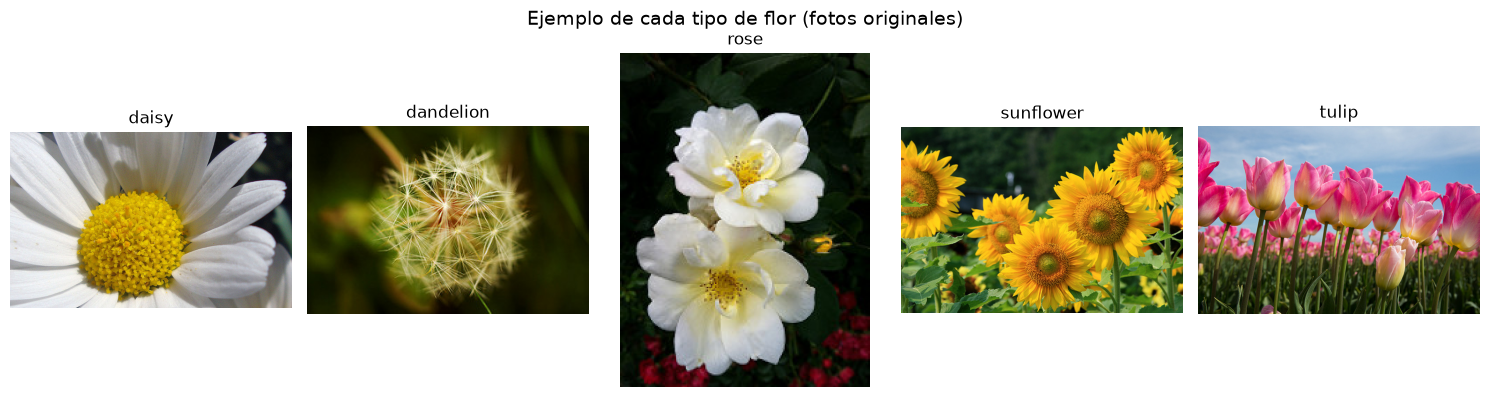

In [27]:
# Verificar que la carpeta de datos existe
data_path = Path(DATA_DIR)
if not data_path.exists():
    print(f"ERROR: No se encuentra la carpeta {DATA_DIR}")
    print("Ejecutá las celdas anteriores primero o verificá la ruta.")
else:
    # Mostrar una foto de cada flor
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    for i, cls in enumerate(CLASSES):
        train_cls = data_path / 'train' / cls
        imgs = [f for f in train_cls.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
        if not imgs:
            print(f"  No se encontraron imágenes en train/{cls}")
            axes[i].set_title(f'{cls}\nsin datos', fontsize=11)
            axes[i].axis('off')
            continue
        img_path = str(imgs[0])
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=12)
        axes[i].axis('off')
    plt.suptitle('Ejemplo de cada tipo de flor (fotos originales)', fontsize=14)
    plt.tight_layout()
    plt.show()


## 4. Data Augmentation

Para evitar que el modelo se aprenda las fotos de memoria (sobreajuste), aplicamos transformaciones aleatorias a las imágenes de entrenamiento:

- **RandomResizedCrop(224):** corta un pedazo al azar y lo redimensiona
- **RandomHorizontalFlip:** voltea la imagen como espejo
- **RandomRotation(20°):** rota hasta 20 grados
- **ColorJitter:** cambia brillo, contraste, saturación y tono al azar

Así el modelo aprende que una rosa sigue siendo una rosa aunque esté rotada, con distinta luz, o recortada.


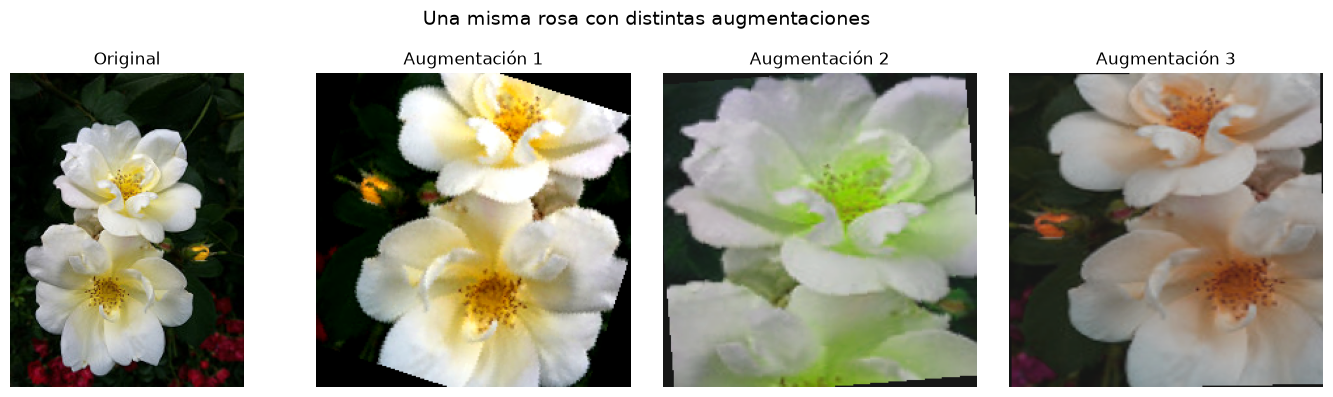

In [28]:
# --- 4. AUMENTAR DATOS (DATA AUGMENTATION) ---

# Las de entrenamiento varían al azar (evita sobreajuste = que memorice fotos de memoria)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),    # Corta un pedazo al azar y lo estira
    transforms.RandomHorizontalFlip(),          # Voltea como espejo
    transforms.RandomRotation(20),              # Rota hasta 20 grados
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Cambia colores
    transforms.ToTensor(),                      # Convierte a formato de PyTorch
    transforms.Normalize(MEAN, STD),            # Ajusta colores al rango que espera el modelo
])

# Las de validación/test son fijas (solo se recorta el centro)
val_transform = transforms.Compose([
    transforms.Resize(256),                     # Redimensiona a 256
    transforms.CenterCrop(IMG_SIZE),            # Recorta el centro a 224x224
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Mostrar una misma rosa con distintas augmentaciones
sample_img_path = list((Path(DATA_DIR) / 'train' / 'rose').glob('*.jpg'))[0]
sample_img = Image.open(sample_img_path)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(sample_img)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

for i in range(3):
    aug = train_transform(sample_img)
    # Desnormalizar para mostrar la imagen en pantalla
    aug_display = aug.numpy().transpose(1,2,0) * np.array(STD) + np.array(MEAN)
    aug_display = np.clip(aug_display, 0, 1)
    axes[i+1].imshow(aug_display)
    axes[i+1].set_title(f'Augmentación {i+1}', fontsize=12)
    axes[i+1].axis('off')

plt.suptitle('Una misma rosa con distintas augmentaciones', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Arquitectura del Modelo: MobileNetV2 + Transfer Learning

**¿Qué es Transfer Learning?** Agarrar un modelo que ya fue entrenado con millones de fotos (ImageNet) y reutilizarlo. No empezamos de cero.

**MobileNetV2:** Una red neuronal creada por Google, liviana y rápida. Ideal para correr en laptops sin GPU.

**El modelo tiene 2 partes:**

1. **Backbone (MobileNetV2):** Las capas que ya saben reconocer bordes, formas y colores. Las CONGELAMOS (no se entrenan).
2. **Classifier (cabeza nueva):** Reemplazamos la capa final por:
   - Dropout(30%) — apaga neuronas al azar para evitar sobreajuste
   - Linear(1280→512) — capa que conecta 1280 números a 512
   - ReLU — deja pasar solo valores positivos
   - Dropout(30%)
   - Linear(512→5) — capa final: 5 salidas (una por cada flor)

Solo el classifier se entrena, el backbone queda fijo.


In [29]:
# --- 5. ARMAR EL MODELO (MOBILENETV2) ---

def build_model(num_classes=5, dropout_rate=0.3):
    # Cargar MobileNetV2 ya entrenado en ImageNet (millones de fotos)
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    # Congelar el backbone (la parte que ya sabe reconocer bordes y formas)
    for param in model.features.parameters():
        param.requires_grad = False  # No se entrena, queda fijo

    # Reemplazar la última capa por una nueva para nuestras 5 flores
    in_features = model.classifier[1].in_features  # 1280 números que salen del backbone
    model.classifier = nn.Sequential(
        nn.Dropout(dropout_rate),          # Apaga neuronas al azar (evita sobreajuste)
        nn.Linear(in_features, 512),       # Capa que conecta 1280 -> 512
        nn.ReLU(inplace=True),             # Deja pasar solo valores positivos
        nn.Dropout(dropout_rate),
        nn.Linear(512, num_classes),       # Capa final: 512 -> 5 salidas (una por flor)
    )
    return model

model = build_model()
print(model)
print(f'\nParámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Parámetros congelados (fijos): {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}')


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

## 6. Entrenamiento

Si ya existe el modelo entrenado, lo cargamos directamente. Si no, lo entrenamos desde cero.

**Early stopping:** Guardamos el modelo cada vez que mejora el accuracy en validación. Al final nos quedamos con el mejor.


In [31]:
# --- 6. FUNCIONES DE ENTRENAMIENTO ---

def get_dataloaders(data_dir, batch_size=32):
    """Prepara los lotes de fotos para entrenar, validar y testear.
    ImageFolder asigna un número a cada carpeta (0=daisy, 1=dandelion...)."""
    data_dir = Path(data_dir)
    train_ds = datasets.ImageFolder(str(data_dir / 'train'), transform=train_transform)
    val_ds = datasets.ImageFolder(str(data_dir / 'val'), transform=val_transform)
    test_ds = datasets.ImageFolder(str(data_dir / 'test'), transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # Mezcla las fotos
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

def train_epoch(model, loader, criterion, optimizer, device):
    """Entrena el modelo por una vuelta completa a los datos de train."""
    model.train()  # Modo entrenamiento (activa dropout)
    total_loss = correct = total = 0
    for images, labels in tqdm(loader, desc='Train'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()          # Limpia gradientes anteriores
        outputs = model(images)        # Pasa las fotos por la red
        loss = criterion(outputs, labels)  # Calcula el error (qué tan mal estuvo)
        loss.backward()                # Calcula cómo ajustar los pesos
        optimizer.step()               # Ajusta los pesos
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)  # La clase con mayor probabilidad
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / total, correct / total  # Error promedio y porcentaje de aciertos

def validate(model, loader, criterion, device):
    """Evalúa el modelo (solo mide, no entrena)."""
    model.eval()  # Modo evaluación (apaga dropout)
    total_loss = correct = total = 0
    with torch.no_grad():  # No calcula gradientes (ahorra memoria)
        for images, labels in tqdm(loader, desc='Val'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return total_loss / total, correct / total


In [32]:
# Cargar los datos
train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR, BATCH_SIZE)
print(f'Batches de train: {len(train_loader)}')  # Lotes de ~32 fotos cada uno
print(f'Batches de val: {len(val_loader)}')
print(f'Batches de test: {len(test_loader)}')


Batches de train: 95
Batches de val: 21
Batches de test: 21


In [33]:
entrenar = False  # Poner True para forzar re-entrenamiento

# Si ya hay modelo guardado, lo carga. Si no, entrena desde cero.
if Path(MODEL_PATH).exists():
    print('Modelo entrenado encontrado. Cargando pesos...')
    model = build_model().to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print('Modelo cargado correctamente.')
else:
    print('No se encontró modelo. Iniciando entrenamiento...')
    entrenar = True

if entrenar:
    model = build_model(dropout_rate=DROPOUT).to(device)
    criterion = nn.CrossEntropyLoss()                      # Error para clasificación
    optimizer = Adam(model.classifier.parameters(), lr=LR) # Solo entrena la última parte

    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Guardar valores para graficar después
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f'Época {epoch:2d}/{EPOCHS}  Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}  Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Guardar el modelo si mejora el accuracy (porcentaje de aciertos) en validación
        if val_acc > best_acc:
            best_acc = val_acc
            Path('models').mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), MODEL_PATH)
            print(f'  -> Guardado mejor modelo (val_acc={val_acc:.4f})')

    print(f'\nEntrenamiento completo. Mejor val_acc: {best_acc:.4f}')

    # Gráfico del error durante el entrenamiento
    plt.figure()
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Loss)')
    plt.legend()
    plt.title('Pérdida durante entrenamiento')
    plt.grid(True)
    plt.savefig('models/loss_plot.png')
    plt.show()
    print('Gráfico de pérdida guardado en models/loss_plot.png')


Modelo entrenado encontrado. Cargando pesos...
Modelo cargado correctamente.


## 7. Evaluación en el conjunto de Test

Medimos el rendimiento del modelo con las fotos de TEST que nunca vio durante el entrenamiento.


In [34]:
# --- 7. EVALUAR EN TEST ---

# Cargar el mejor modelo
model = build_model().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

all_preds = []   # Lo que el modelo predijo
all_labels = []  # Lo que realmente era

# Pasar todas las fotos de test por el modelo
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluando'):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)  # Agarrar la clase con mayor puntaje
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calcular métricas
accuracy = (all_preds == all_labels).mean()                            # % de aciertos
f1_macro = f1_score(all_labels, all_preds, average='macro')            # Promedio de F1 entre clases
f1_per_class = f1_score(all_labels, all_preds, average=None)           # F1 de cada clase por separado
cm = confusion_matrix(all_labels, all_preds)                           # Tabla de aciertos vs errores

print(f'Accuracy en test: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Macro F1-Score: {f1_macro:.4f}')
print()
print('F1-Score por clase:')
for cls_name, f1 in zip(CLASSES, f1_per_class):
    print(f'  {cls_name:12s}: {f1:.4f}')


Evaluando: 100%|██████████| 21/21 [00:06<00:00,  3.03it/s]

Accuracy en test: 0.9037 (90.37%)
Macro F1-Score: 0.9047

F1-Score por clase:
  daisy       : 0.9251
  dandelion   : 0.9119
  rose        : 0.8761
  sunflower   : 0.9327
  tulip       : 0.8779


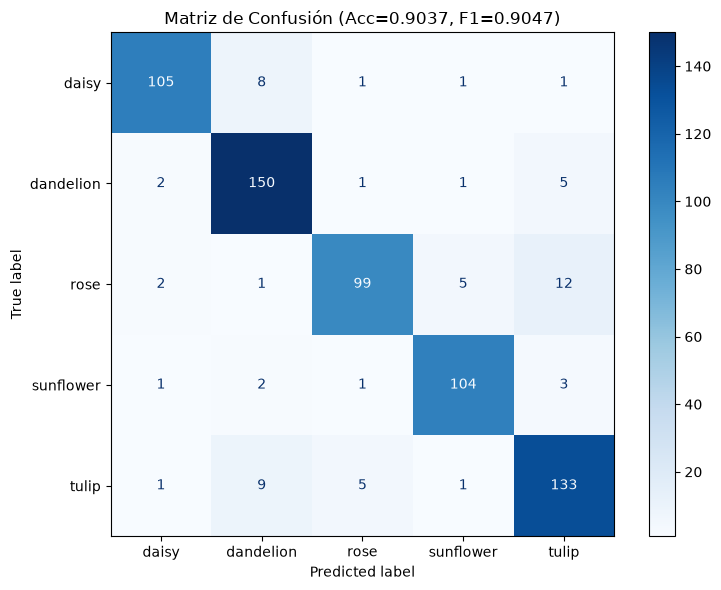

Matriz de confusión guardada en models/confusion_matrix.png


In [35]:
# Matriz de confusión: diagonales = aciertos, fuera de diagonal = errores
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Matriz de Confusión (Acc={accuracy:.4f}, F1={f1_macro:.4f})')
plt.tight_layout()
Path('models').mkdir(parents=True, exist_ok=True)  # Crear carpeta si no existe
plt.savefig('models/confusion_matrix.png')
plt.show()
print('Matriz de confusión guardada en models/confusion_matrix.png')


## 8. Inferencia: Probar el modelo con una imagen nueva

Tomamos una foto del conjunto de test, la pasamos por el modelo, y vemos qué predice junto con el nivel de confianza.


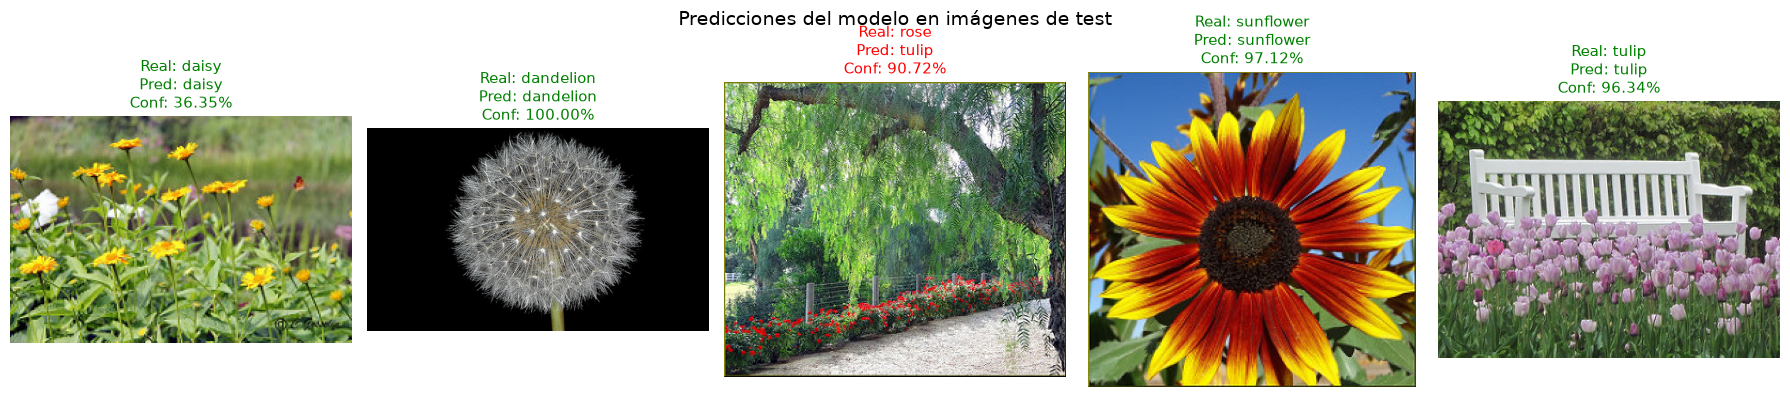

In [36]:
# --- 8. PROBAR EL MODELO ---

def predict(image_path, model, class_names, transform, device):
    """Toma una foto, la pasa por el modelo y devuelve (clase, confianza)."""
    image = Image.open(image_path).convert('RGB')                     # Cargar la foto
    input_tensor = transform(image).unsqueeze(0).to(device)           # Transformar y agregar batch

    with torch.no_grad():
        outputs = model(input_tensor)                                 # Pasar por la red
        probabilities = torch.nn.functional.softmax(outputs, dim=1)   # Convertir a probabilidades (0 a 1)
        confidence, predicted = torch.max(probabilities, 1)           # Clase con mayor probabilidad

    return class_names[predicted.item()], confidence.item()

# Probar 1 foto de cada clase para ver resultados
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, cls in enumerate(CLASSES):
    test_imgs = list((Path(DATA_DIR) / 'test' / cls).glob('*'))
    if not test_imgs:
        continue
    img_path = str(test_imgs[0])
    real_class = cls
    pred_class, confidence = predict(img_path, model, CLASSES, val_transform, device)

    img = Image.open(img_path)
    axes[i].imshow(img)
    color = 'green' if pred_class == real_class else 'red'  # Verde = bien, rojo = mal
    axes[i].set_title(f'Real: {real_class}\nPred: {pred_class}\nConf: {confidence:.2%}',
                      fontsize=11, color=color)
    axes[i].axis('off')

plt.suptitle('Predicciones del modelo en imágenes de test', fontsize=14)
plt.tight_layout()
plt.show()


### 8.1 Probar con una imagen nueva (la que quieras)

Podés cambiar la ruta en la siguiente celda para probar cualquier foto de flor que tengas.


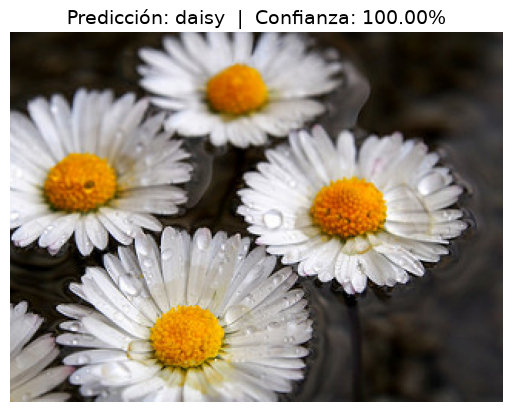

Predicción: daisy
Confianza: 1.0000 (100.0%)


In [37]:
# Probar con UNA foto propia (CAMBIAR la ruta)
from pathlib import Path

# Encontrar la carpeta raíz del proyecto
def find_project_root():
    current = Path.cwd()
    while not (current / '.git').exists():
        current = current.parent
        if current.parent == current:
            return Path.cwd()
    return current

PROJECT_ROOT = find_project_root()


# CAMBIA ESTA RUTA por la imagen que quieras probar
# ruta_imagen = str(PROJECT_ROOT / 'data' / 'split' / 'test' / 'daisy' / '10300722094_28fa978807_n.jpg')
ruta_imagen = str(PROJECT_ROOT / 'pruebas' / '7.jpg')
if Path(ruta_imagen).exists():
    pred_class, confidence = predict(ruta_imagen, model, CLASSES, val_transform, device)
    img = Image.open(ruta_imagen)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Predicción: {pred_class}  |  Confianza: {confidence:.2%}', fontsize=14)
    plt.show()
    print(f'Predicción: {pred_class}')
    print(f'Confianza: {confidence:.4f} ({confidence*100:.1f}%)')
else:
    print(f'Error: la ruta {ruta_imagen} no existe. Cambiala por una ruta válida.')
